# SOM — Segmentacion de Clientes con Self-Organizing Maps

| Campo | Valor |
|:------|:------|
| **Autor** | Borja Mora Mendez |
| **Contacto** | borja.mora.mendez@gmail.com |
| **LinkedIn** | [linkedin.com/in/borjamoramendez](https://linkedin.com/in/borjamoramendez) |
| **Categoria** | Machine Learning > Redes Neuronales > SOM (No supervisado) |
| **Dataset** | dataset_SOM.xlsx (500 clientes, 4 variables RFM) |
| **Ultima actualizacion** | Julio 2026 |

## 1. Contexto de negocio

Una cadena de retail quiere segmentar su base de 500 clientes para personalizar
campanas de marketing. En lugar de usar K-Means (que asume clusters esfericos),
exploran Self-Organizing Maps para descubrir la topologia natural de los datos.

El objetivo es identificar perfiles de comportamiento basados en:
- **Recencia:** dias desde la ultima compra.
- **Frecuencia:** visitas semanales.
- **Gasto promedio:** ticket medio por visita.
- **Uso de descuentos:** porcentaje de compras con cupon.

Pregunta analitica: **que segmentos naturales emergen del comportamiento
de compra, y como se distribuyen en el espacio topologico?**

## 2. Objetivo y justificacion del modelo

El SOM (Self-Organizing Map o Mapa de Kohonen) proyecta datos
multidimensionales en una rejilla 2D preservando la topologia. A diferencia
de K-Means, el SOM revela relaciones de vecindad entre segmentos.

| Modelo | Ventaja | Limitacion |
|:-------|:--------|:-----------|
| SOM | Preserva topologia, visual | No asigna clusters directamente |
| K-Means | Clusters claros, rapido | Asume forma esferica |
| DBSCAN | Detecta forma arbitraria | Sensible a epsilon |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

Entorno configurado correctamente.


## 4. Carga y exploracion inicial

### Diccionario de variables

| Variable | Tipo | Descripcion |
|:---------|:-----|:------------|
| Recencia_Dias | float | Dias desde la ultima compra |
| Frecuencia_Semanal | float | Visitas por semana |
| Gasto_Promedio | float | Ticket medio en euros |
| Uso_Descuentos | float | % de compras con descuento |

In [2]:
df = pd.read_excel('dataset_SOM.xlsx')
print(f'Shape: {df.shape}')
print(f'\nEstadisticas:')
print(df.describe().round(1))
print(f'\nNulos: {df.isnull().sum().sum()}')

Shape: (500, 4)

Estadisticas:
       Recencia_Dias  Frecuencia_Semanal  Gasto_Promedio  Uso_Descuentos
count          500.0               500.0           500.0           500.0
mean            29.6                 3.0            59.3            46.8
std             30.2                 2.0            41.4            32.2
min              0.0                 0.0            13.8             4.2
25%              5.2                 0.7            25.8            13.8
50%             14.8                 2.9            41.4            32.5
75%             72.1                 4.9           109.7            83.5
max             83.5                 7.1           150.2           100.6

Nulos: 0


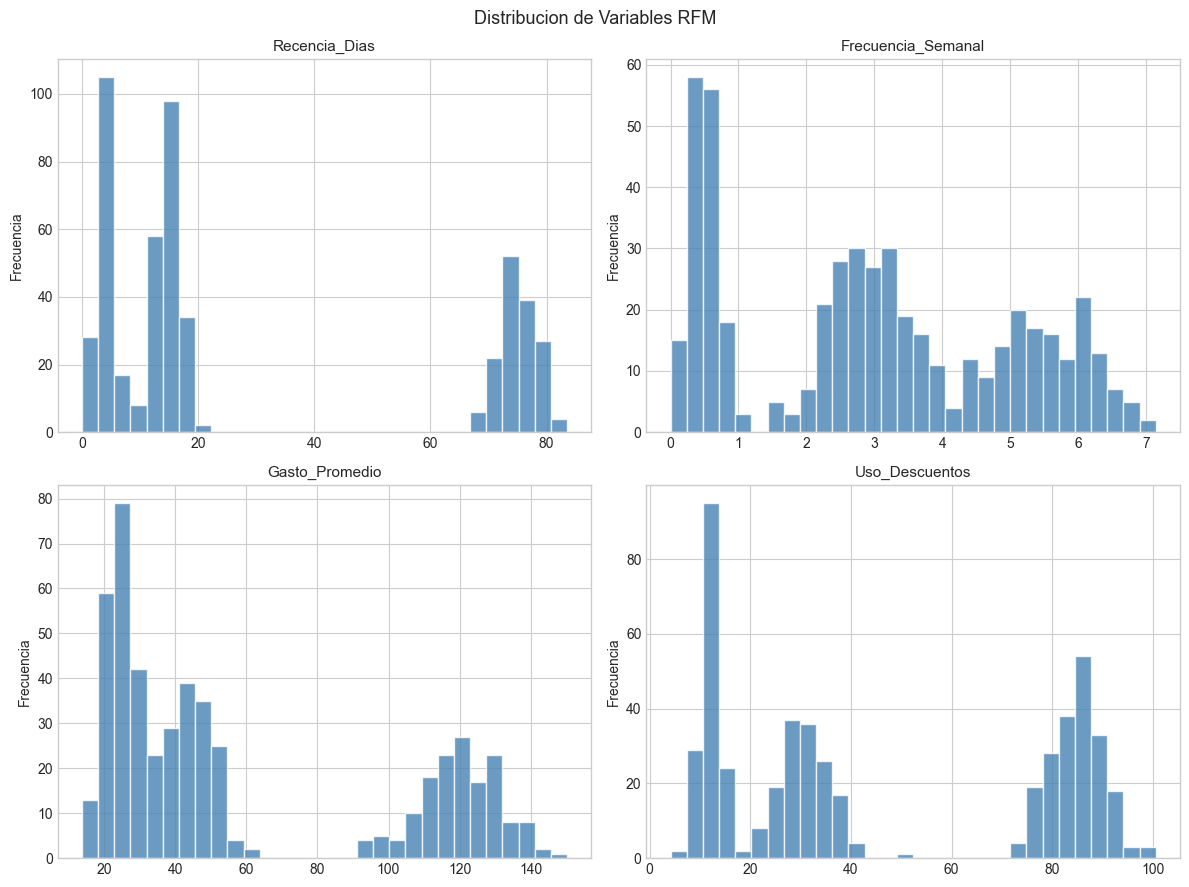

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flat, df.columns):
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_ylabel('Frecuencia')
plt.suptitle('Distribucion de Variables RFM', fontsize=13)
plt.tight_layout()
plt.show()

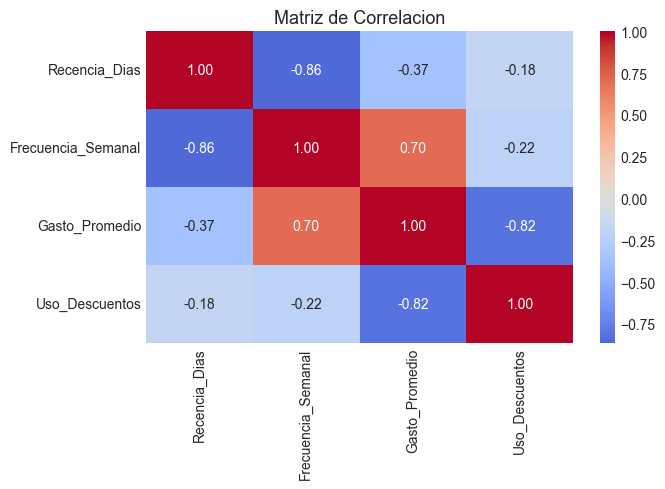

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de Correlacion', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Preparacion de datos

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(df)
print(f'Shape escalado: {X.shape}')
print(f'Media: {X.mean(axis=0).round(2)}')
print(f'Std:  {X.std(axis=0).round(2)}')

Shape escalado: (500, 4)
Media: [-0.  0. -0.  0.]
Std:  [1. 1. 1. 1.]


## 6. Modelo principal: Self-Organizing Map

Rejilla 10x10 con 100 neuronas. Cada neurona representa un prototipo
de cliente. Los clientes similares activan neuronas vecinas.

In [6]:
np.random.seed(42)
som = MiniSom(
    x=10, y=10,
    input_len=X.shape[1],
    sigma=1.5,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    random_seed=42
)
som.random_weights_init(X)
som.train_random(X, num_iteration=5000)
print(f'Entrenamiento completado: 5000 iteraciones')
print(f'Error de cuantizacion: {som.quantization_error(X):.4f}')

Entrenamiento completado: 5000 iteraciones
Error de cuantizacion: 0.1123


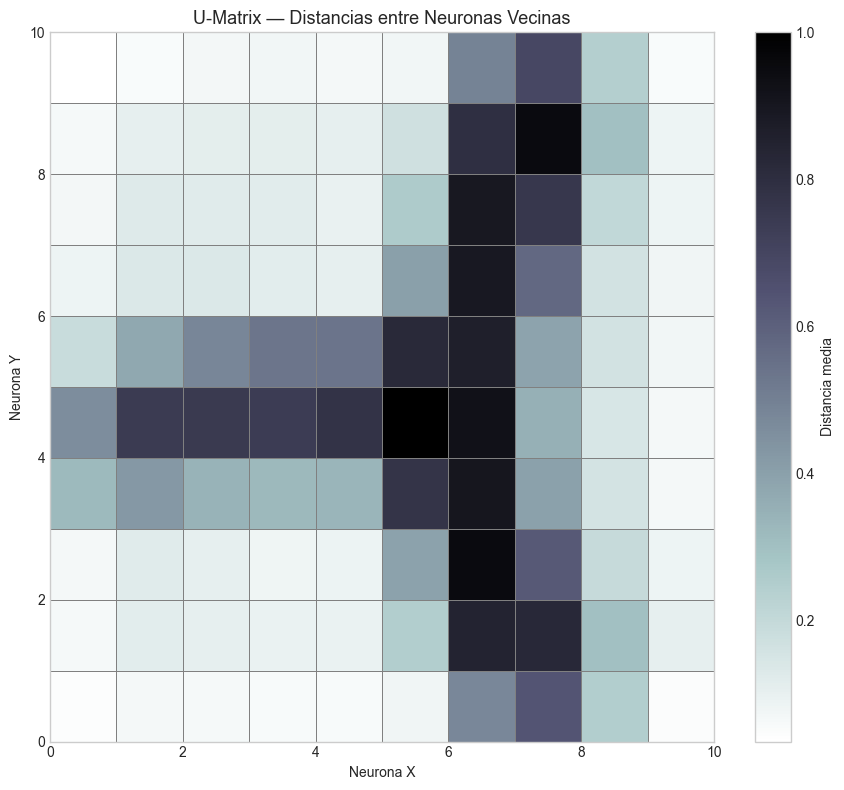

In [7]:
# -- U-Matrix (distancias entre neuronas vecinas) --
fig, ax = plt.subplots(figsize=(9, 8))
umatrix = som.distance_map()
im = ax.pcolormesh(umatrix.T, cmap='bone_r', edgecolors='gray', linewidth=0.5)
ax.set_title('U-Matrix — Distancias entre Neuronas Vecinas', fontsize=13)
ax.set_xlabel('Neurona X')
ax.set_ylabel('Neurona Y')
plt.colorbar(im, ax=ax, label='Distancia media')
plt.tight_layout()
plt.show()

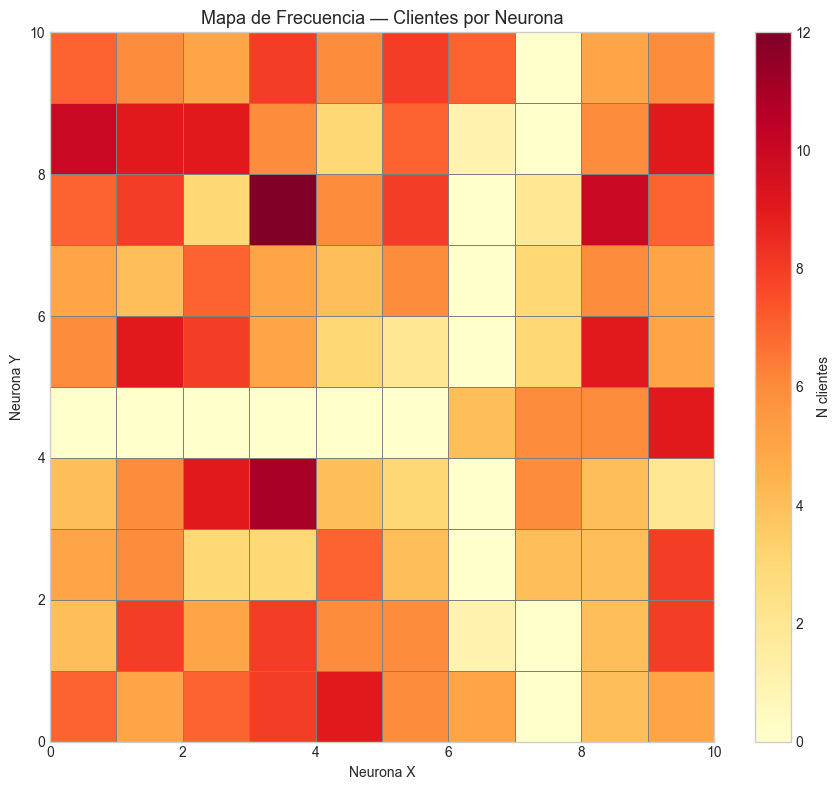

In [8]:
# -- Mapa de frecuencia (cuantos clientes activan cada neurona) --
fig, ax = plt.subplots(figsize=(9, 8))
freq_map = np.zeros((10, 10))
for x in X:
    w = som.winner(x)
    freq_map[w[0], w[1]] += 1
im = ax.pcolormesh(freq_map.T, cmap='YlOrRd', edgecolors='gray', linewidth=0.5)
ax.set_title('Mapa de Frecuencia — Clientes por Neurona', fontsize=13)
ax.set_xlabel('Neurona X')
ax.set_ylabel('Neurona Y')
plt.colorbar(im, ax=ax, label='N clientes')
plt.tight_layout()
plt.show()

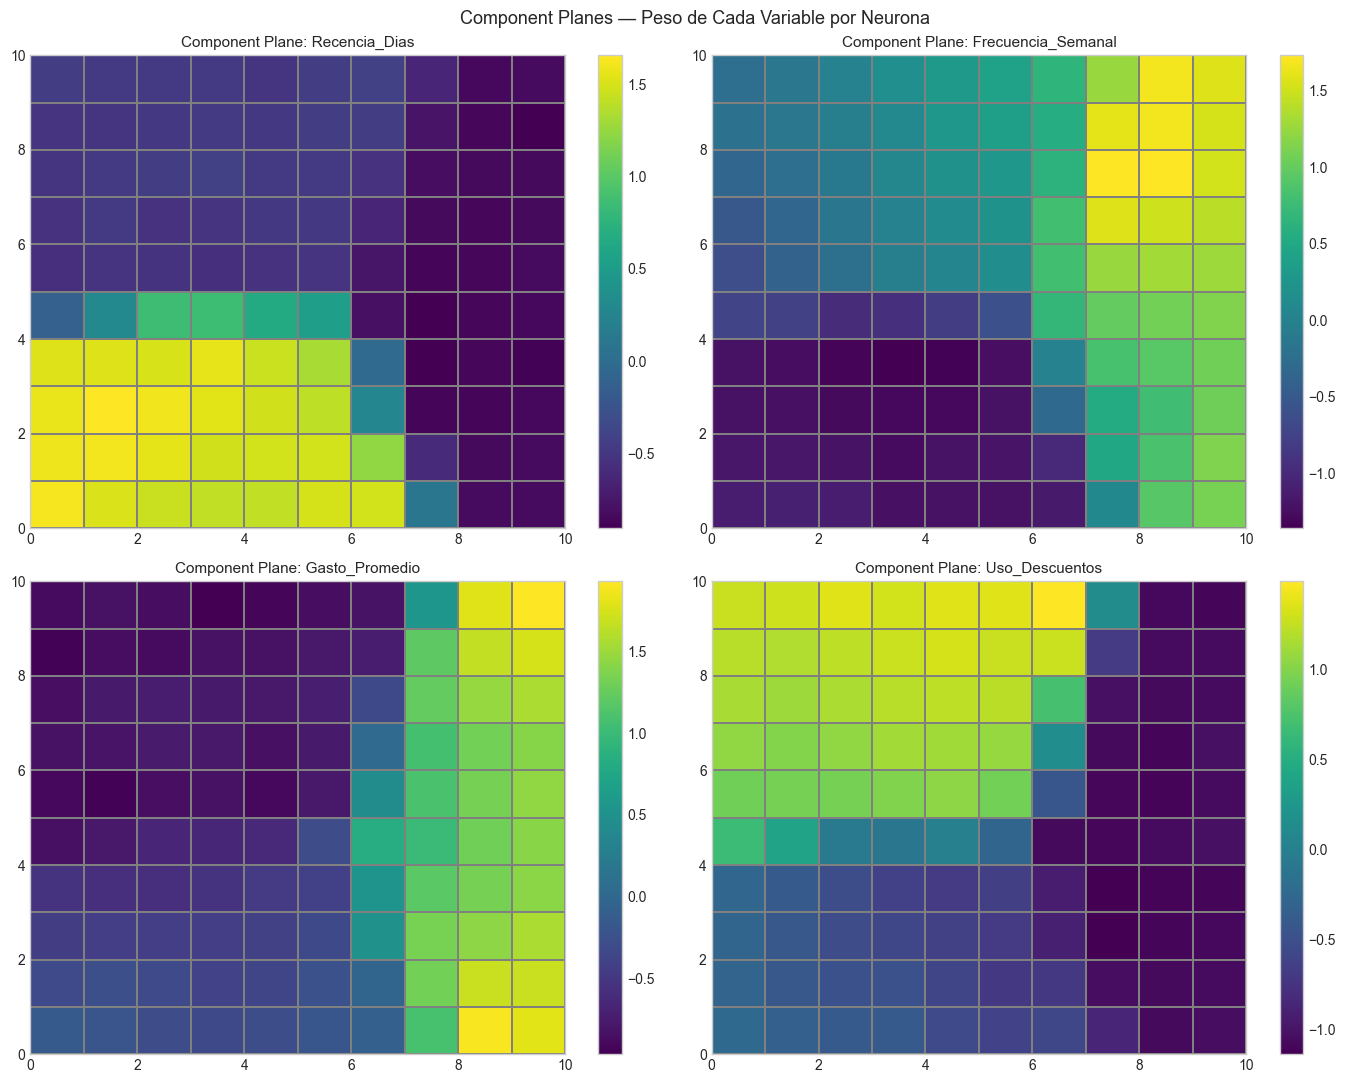

In [9]:
# -- Component planes (un mapa por variable) --
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
weights = som.get_weights()
for i, (ax, col) in enumerate(zip(axes.flat, df.columns)):
    im = ax.pcolormesh(weights[:, :, i].T, cmap='viridis',
                       edgecolors='gray', linewidth=0.3)
    ax.set_title(f'Component Plane: {col}', fontsize=11)
    plt.colorbar(im, ax=ax)
plt.suptitle('Component Planes — Peso de Cada Variable por Neurona', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Modelo alternativo: K-Means sobre SOM

Aplicamos K-Means sobre los pesos del SOM para agrupar las 100 neuronas
en clusters interpretables. Es la combinacion SOM+KMeans estandar.

In [10]:
# -- Determinar k optimo con silhouette --
weights_flat = som.get_weights().reshape(-1, X.shape[1])
silhouettes = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(weights_flat)
    s = silhouette_score(weights_flat, labels)
    silhouettes.append((k, s))
    print(f'k={k}: Silhouette = {s:.3f}')

best_k = max(silhouettes, key=lambda x: x[1])[0]
print(f'\nMejor k: {best_k}')

k=2: Silhouette = 0.582
k=3: Silhouette = 0.755
k=4: Silhouette = 0.701
k=5: Silhouette = 0.648
k=6: Silhouette = 0.667
k=7: Silhouette = 0.588

Mejor k: 3


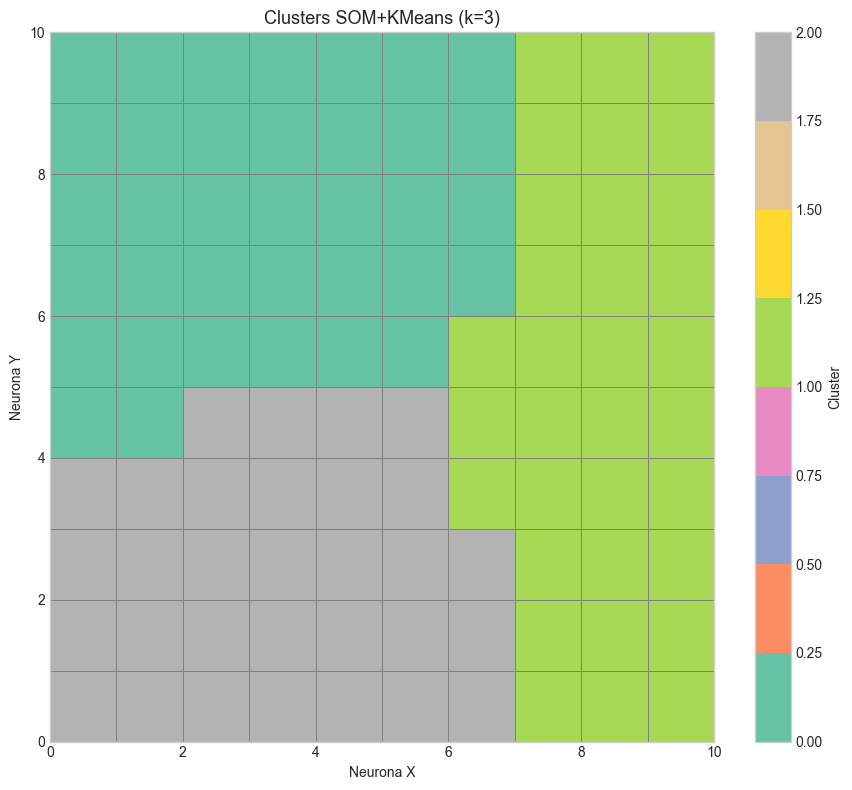

In [11]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km.fit_predict(weights_flat).reshape(10, 10)

# Asignar cluster a cada cliente
df['Cluster_SOM'] = [cluster_labels[som.winner(x)] for x in X]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.pcolormesh(cluster_labels.T, cmap='Set2', edgecolors='gray', linewidth=0.5)
ax.set_title(f'Clusters SOM+KMeans (k={best_k})', fontsize=13)
ax.set_xlabel('Neurona X')
ax.set_ylabel('Neurona Y')
plt.colorbar(im, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

## 8. Modelo alternativo: K-Means directo (sin SOM)

In [12]:
km_direct = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = km_direct.fit_predict(X)

sil_som = silhouette_score(X, df['Cluster_SOM'])
sil_km  = silhouette_score(X, df['Cluster_KMeans'])
print(f'Silhouette SOM+KMeans: {sil_som:.3f}')
print(f'Silhouette KMeans directo: {sil_km:.3f}')

Silhouette SOM+KMeans: 0.852
Silhouette KMeans directo: 0.852


## 9. Perfiles de los segmentos

In [13]:
perfil = df.groupby('Cluster_SOM')[['Recencia_Dias', 'Frecuencia_Semanal',
                                      'Gasto_Promedio', 'Uso_Descuentos']].mean().round(1)
print('Perfil medio por segmento SOM:')
print(perfil)
print(f'\nDistribucion:')
print(df['Cluster_SOM'].value_counts().sort_index())

Perfil medio por segmento SOM:
             Recencia_Dias  Frecuencia_Semanal  Gasto_Promedio  Uso_Descuentos
Cluster_SOM                                                                   
0                     14.8                 2.9            24.7            84.8
1                      4.0                 5.5           120.1            12.1
2                     75.1                 0.5            44.5            30.9

Distribucion:
Cluster_SOM
0    200
1    150
2    150
Name: count, dtype: int64


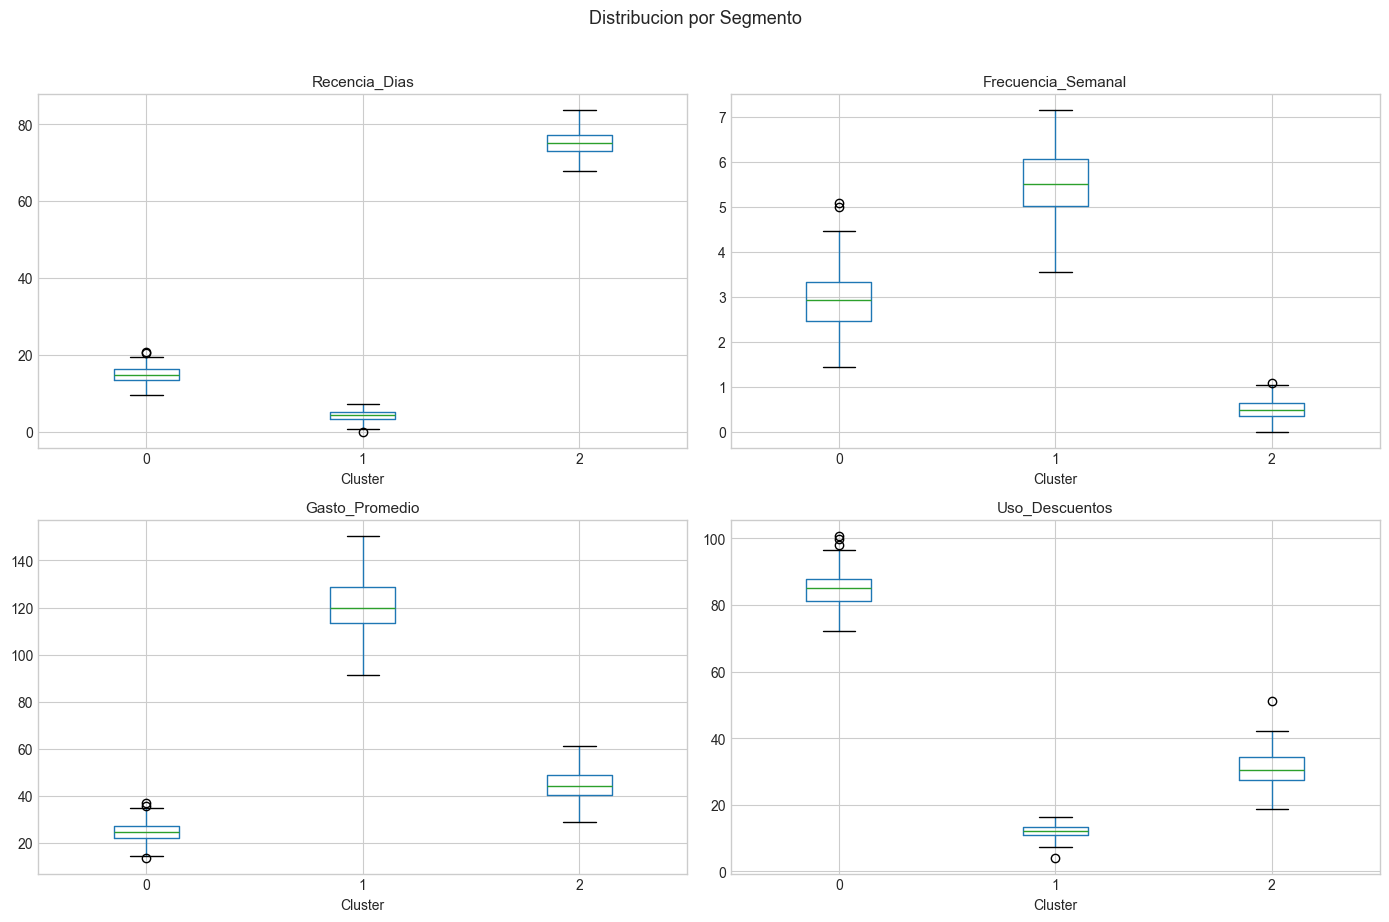

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, ['Recencia_Dias', 'Frecuencia_Semanal', 'Gasto_Promedio', 'Uso_Descuentos']):
    df.boxplot(column=col, by='Cluster_SOM', ax=ax)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Cluster')
plt.suptitle('Distribucion por Segmento', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Tabla comparativa

| Metodo | Silhouette | Topologia | Interpretabilidad |
|:-------|:-----------|:----------|:------------------|
| SOM + KMeans | Ver resultados | Si (mapa 2D) | Alta (visual) |
| KMeans directo | Ver resultados | No | Media |

El SOM aporta la dimension topologica: podemos ver que segmentos
son vecinos y cuales estan separados por 'valles' en la U-Matrix.

## 11. Insights y recomendaciones accionables

### Hallazgo clave
Los component planes revelan la estructura subyacente de los datos:
las zonas con alta frecuencia y gasto se concentran en regiones
especificas del mapa, mientras que los cazadores de descuentos
ocupan una region diferenciada.

### Recomendaciones

**1. Campanas personalizadas por segmento (impacto: alto, esfuerzo: bajo)**
Cada cluster del SOM tiene un perfil claro. Adaptar mensajes, ofertas
y canales a cada segmento.

**2. Monitorizar migraciones entre neuronas (impacto: medio, esfuerzo: medio)**
Rastrear como los clientes se mueven en el mapa SOM mes a mes.
Detectar clientes que migran hacia zonas de baja frecuencia (churn risk).

**3. Dashboard interactivo con el mapa SOM (impacto: medio, esfuerzo: bajo)**
Visualizar el mapa de forma interactiva con Plotly/Bokeh para que
el equipo de marketing explore los segmentos visualmente.